In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/breast-cancer-dataset/breast-cancer.csv


## Libraries

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Data load

In [3]:
df = pd.read_csv('/kaggle/input/datasets/yasserh/breast-cancer-dataset/breast-cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:

df.info()
print("------------ Data type -------------")
print(df.dtypes)
print("------------- Categorical Columns -------------------")
# Select only columns that are text (object) or category types
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Categorical columns in the dataset:")
print(list(categorical_cols))
print("-------------------- Unique values in diagnosis -----------------")
# See all unique entries in the 'Country' column
print(df['diagnosis'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
# Drop the  'id' column

df = df.drop(columns=['id'] , errors='ignore')
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
# X takes everything EXCEPT the 'diagnosis' column
X = df.drop(columns=['diagnosis'])

# y takes ONLY the 'diagnosis' column
y = df['diagnosis']
print("-------------------- features X ----------------")
X.head()



-------------------- features X ----------------


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
print("-------------------- Target y -----------------")
y.head()

-------------------- Target y -----------------


0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: object

In [8]:
y = df['diagnosis'].map({'B': 0, 'M': 1})
y.head()

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

In [9]:
# Print the shapes of the resulting splits
print(f"X shape: {X.shape} ")
print(f"y shape: {y.shape} ")

X shape: (569, 30) 
y shape: (569,) 


## Test train split

In [10]:
# 2. Perform the Train-Test Split
# test_size=0.2 means 20% of the data goes to the test set, 80% to training.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Print the shapes of the resulting splits
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (455, 30)
y_train shape: (455,)
X_test shape:  (114, 30)
y_test shape:  (114,)


In [11]:
# 3. Apply Standardization (Scale the features)
scaler = StandardScaler()

# Fit ONLY on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the parameters learned from the training data
X_test_scaled = scaler.transform(X_test)

In [12]:
# Convert back to DataFrame using original column names and test indices
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

print("Clean DataFrame View of Scaled Test Data:")
X_train_scaled_df.head()

Clean DataFrame View of Scaled Test Data:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
10,0.518559,0.891826,0.424632,0.383925,-0.974744,-0.689772,-0.688586,-0.398175,-1.039155,-0.825056,...,0.579798,1.313242,0.466908,0.445983,-0.596155,-0.634722,-0.610227,-0.235744,0.054566,0.021837
170,-0.516364,-1.639710,-0.541349,-0.542961,0.476219,-0.631834,-0.604281,-0.303075,0.521543,-0.454523,...,-0.582459,-1.690291,-0.611934,-0.587014,0.273582,-0.814844,-0.712666,-0.323208,-0.137576,-0.904402
407,-0.368118,0.455515,-0.388250,-0.402970,-1.432979,-0.383927,-0.342175,-0.765459,-0.850857,-0.226171,...,-0.398622,0.181977,-0.475431,-0.420778,-1.622785,-0.391399,-0.431313,-0.890825,-0.675893,-0.144016
430,0.205285,0.726168,0.400330,0.070612,0.243253,2.203585,2.256094,1.213233,0.818474,0.899791,...,-0.000309,0.274191,0.513776,-0.099482,0.418538,2.865970,2.958619,1.977064,-0.075646,1.728848
27,1.243005,0.194195,1.210377,1.206652,-0.111442,0.051348,0.732962,0.713767,-0.427187,-0.822184,...,1.012835,0.223144,0.938517,0.880910,0.073201,-0.277006,0.327775,0.501859,-0.909322,-0.546249


## Correlation of heatmap

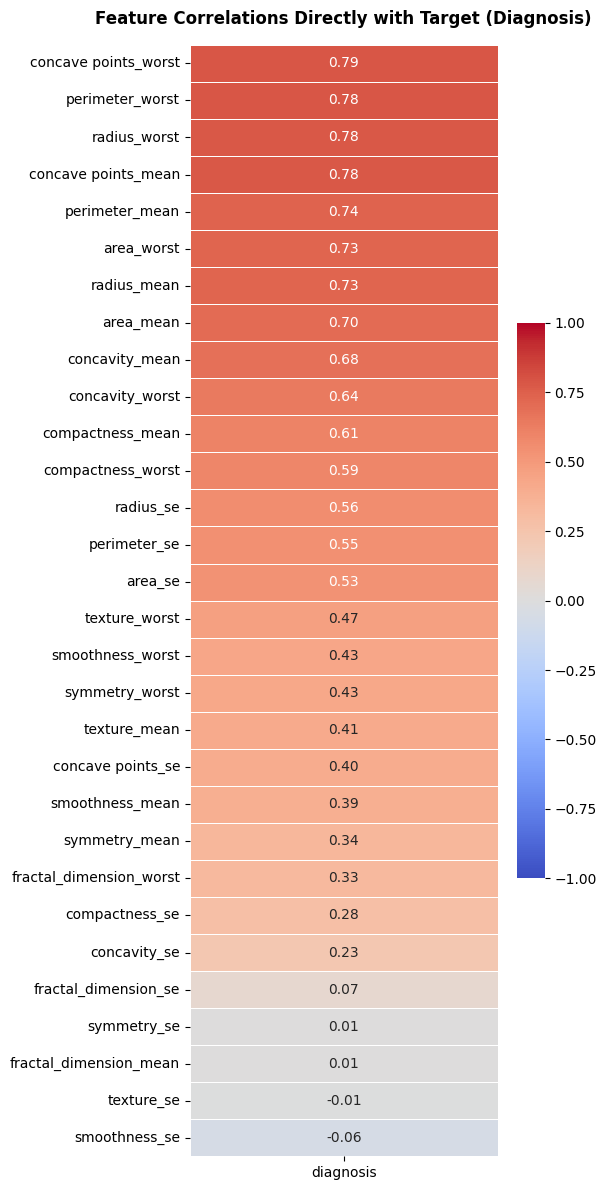

In [13]:


# 1. Combine X_train and y_train safely
train_df = X_train.copy()
train_df["diagnosis"] = y_train

# 2. Calculate the matrix, but slice out ONLY the 'diagnosis' column
# We sort the values so the strongest predictors are right at the top
target_corr = (
    train_df.corr(numeric_only=True)[["diagnosis"]]
    .sort_values(by="diagnosis", ascending=False)
)

# 3. Drop the target's correlation with itself (which is always 1.0)
target_corr = target_corr.drop("diagnosis")

# 4. Set up a tall, narrow plotting window suited for a single column
plt.figure(figsize=(6, 12))

# 5. Draw the single-column heatmap
sns.heatmap(
    target_corr,
    annot=True,  # Shows exact correlation coefficients
    cmap="coolwarm",  # Red = promotes target, Blue = protects against target
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
)

# Clean up layout adjustments
plt.title(
    "Feature Correlations Directly with Target (Diagnosis)",
    fontsize=12,
    pad=15,
    weight="bold",
)
plt.tight_layout()
plt.show()

## Data visulaization 

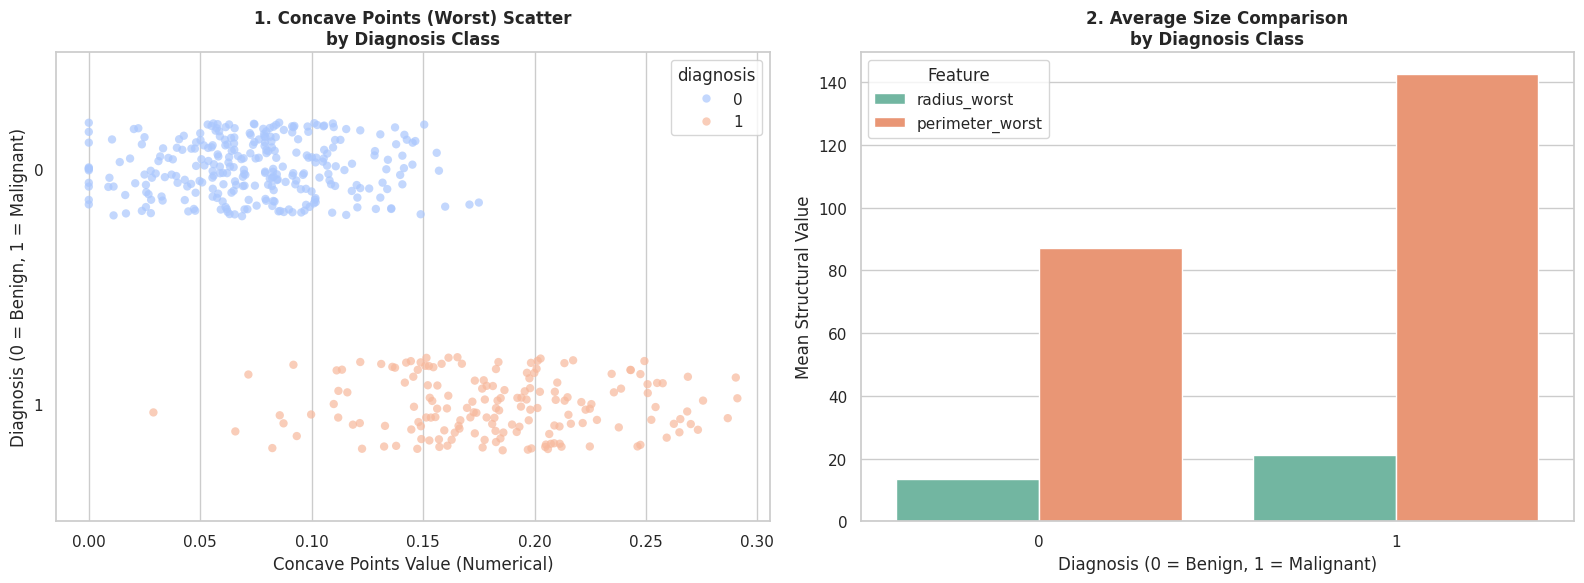

In [14]:


# Set a clean visual style
sns.set_theme(style="whitegrid")

# Create a 1-row, 2-column layout canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAPH 1: Scatter (Strip/Swarm) Plot for concave points_worst by diagnosis ---
# Since diagnosis is categorical (0 or 1), a stripplot spreads the points out cleanly
sns.stripplot(
    ax=axes[0],
    data=train_df,
    x="concave points_worst",
    y="diagnosis",
    hue="diagnosis",
    orient="h",  # Horizontal orientation to clearly read values on the X-axis
    palette="coolwarm",
    alpha=0.7,
    size=6,
    jitter=0.2,  # Adds a slight spread so overlapping dots are visible
)
axes[0].set_title(
    "1. Concave Points (Worst) Scatter\nby Diagnosis Class",
    fontsize=12,
    weight="bold",
)
axes[0].set_xlabel("Concave Points Value (Numerical)")
axes[0].set_ylabel("Diagnosis (0 = Benign, 1 = Malignant)")

# --- GRAPH 2: Grouped Bar Plot for radius_worst & perimeter_worst by diagnosis ---
# First, we restructure the data so both features can be plotted on the same bar chart
melted_df = train_df.melt(
    id_vars=["diagnosis"],
    value_vars=["radius_worst", "perimeter_worst"],
    var_name="Feature",
    value_name="Average Value",
)

# Plot the average values side-by-side
sns.barplot(
    ax=axes[1],
    data=melted_df,
    x="diagnosis",
    y="Average Value",
    hue="Feature",
    palette="Set2",
    errorbar=None,  # Removes the error line to keep the bars completely clean
)
axes[1].set_title(
    "2. Average Size Comparison\nby Diagnosis Class", fontsize=12, weight="bold"
)
axes[1].set_xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
axes[1].set_ylabel("Mean Structural Value")

# Adjust spacing between plots and render
plt.tight_layout()
plt.show()

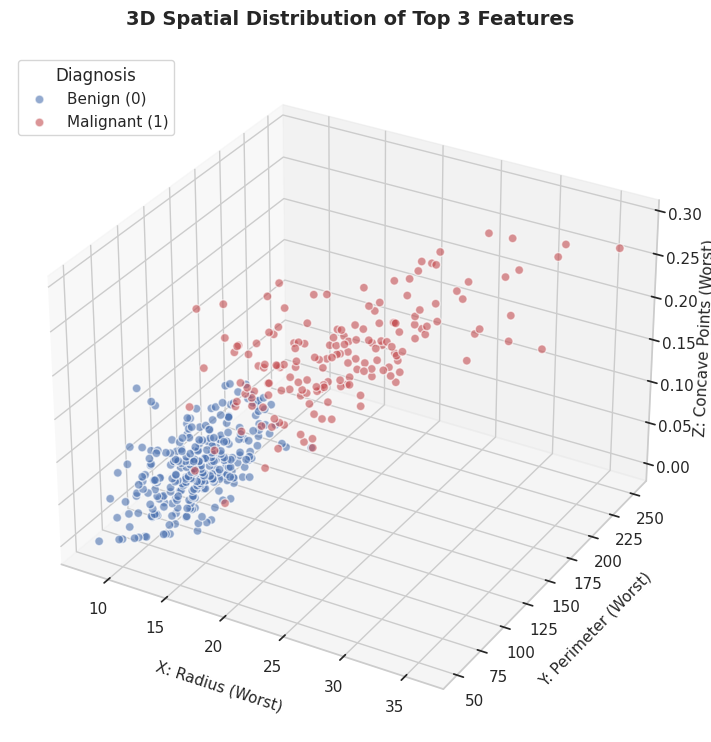

In [15]:


# 1. Set up the figure canvas for a 3D projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# 2. Split the data by diagnosis class for distinct labeling
benign = train_df[train_df["diagnosis"] == 0]
malignant = train_df[train_df["diagnosis"] == 1]

# 3. Scatter plot for Benign (Class 0) - Using Blue
ax.scatter(
    benign["radius_worst"],
    benign["perimeter_worst"],
    benign["concave points_worst"],
    c="#4C72B0",
    label="Benign (0)",
    alpha=0.6,
    edgecolors="w",
    s=40,
)

# 4. Scatter plot for Malignant (Class 1) - Using Red
ax.scatter(
    malignant["radius_worst"],
    malignant["perimeter_worst"],
    malignant["concave points_worst"],
    c="#C44E52",
    label="Malignant (1)",
    alpha=0.6,
    edgecolors="w",
    s=40,
)

# --- THE CORRECTION FIXES HERE ---
# By default, Matplotlib flings the Z-label out of bounds. 
# We use a negative labelpad (-1 or -2) to pull it inward toward the chart grid lines.
ax.set_xlabel("X: Radius (Worst)", fontsize=11, labelpad=10)
ax.set_ylabel("Y: Perimeter (Worst)", fontsize=11, labelpad=10)
ax.set_zlabel("Z: Concave Points (Worst)", fontsize=11, labelpad= 2) 

# Adjust the camera viewing margins to give the text breathing room on the edges
ax.dist = 11  # Extends the window boundaries slightly outward

# Final title and layout optimization
ax.set_title(
    "3D Spatial Distribution of Top 3 Features", fontsize=14, weight="bold", pad=20
)
ax.legend(title="Diagnosis", loc="upper left")

# Replaced tight_layout() with explicit subplots_adjust to prevent clipping bugs
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.9)
plt.show()

## Train model 

In [16]:
# Find which SVM Model will be best fit using gird search cv

param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]  # gamma is ignored by the linear kernel automatically
}

# 3. Set up the Grid Search with 5-fold cross-validation
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

# 4. Print your absolute best fit configuration
print(f"Best Parameters Found: {grid.best_params_}")
print(f"Best Validation Accuracy: {grid.best_score_:.4f}")

# 5. Extract the optimized model directly
best_svm_model = grid.best_estimator_

Best Parameters Found: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Validation Accuracy: 0.9758


In [17]:
# Use the optimized model to make classification predictions
y_pred = best_svm_model.predict(X_test_scaled)


In [18]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy: {accuracy * 100:.2f}%")

Model accuracy: 97.37%


## Confusion Matrix


Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



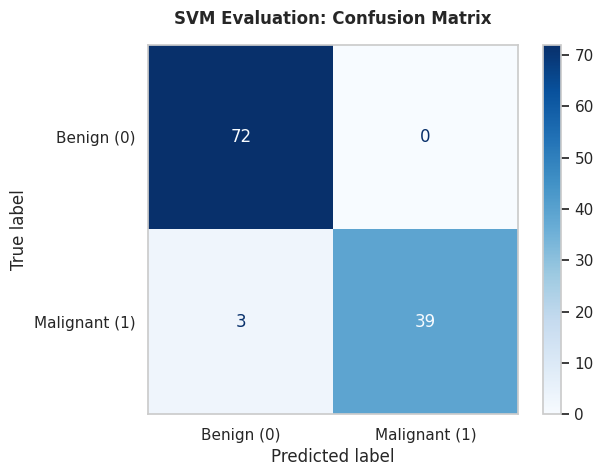

In [19]:

# Generate the confusion matrix data
cm = confusion_matrix(y_test, y_pred)

# Display it clearly
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign (0)", "Malignant (1)"])
disp.plot(cmap="Blues")

plt.title("SVM Evaluation: Confusion Matrix", weight="bold", pad=15)
plt.grid(False) # Clean look
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))
plt.show()